This project analyzes Tesla's delivery dataset from 2015 to 2025 using Python. The objective is to explore the data, derive useful features, build machine learning models, evaluate their performance, and forecast vehicle deliveries. The project follows a complete data science workflow including data preprocessing, visualization, model training, cross-validation, hyperparameter tuning, and time series analysis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

##Dataset

####The dataset contains Tesla vehicle delivery information from 2015 to 2025. It includes numerical and categorical features such as model type, production units, battery capacity, average price, charging stations, estimated deliveries, and regional information. These variables help understand production trends and predict future deliveries.

In [ ]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

In [ ]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [ ]:
df.shape

(2640, 12)

In [ ]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [ ]:
df.info

<bound method DataFrame.info of       Year  Month         Region       Model  Estimated_Deliveries  \
0     2023      5         Europe     Model S                 17646   
1     2015      2           Asia     Model X                  3797   
2     2019      1  North America     Model X                  8411   
3     2021      2  North America     Model 3                  6555   
4     2016     12    Middle East     Model Y                 12374   
...    ...    ...            ...         ...                   ...   
2635  2021     10    Middle East     Model Y                 13488   
2636  2019      7    Middle East     Model S                 18300   
2637  2019      9           Asia     Model S                 13291   
2638  2020      5           Asia  Cybertruck                  3471   
2639  2018      8  North America     Model S                  2639   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0                17922       92874.27                   120       704   
1                 4164       62205.65                    75       438   
2                 9189      117887.32                    82       480   
3                 7311       89294.91                   120       712   
4                13537      114846.78                   120       661   
...                ...            ...                   ...       ...   
2635             14333      113771.10                   120       719   
2636             18407       81889.67                    82       487   
2637             14839       97139.38                   100       580   
2638              3714       69990.57                    60       358   
2639              2929       51676.24                    82       474   

      CO2_Saved_tons           Source_Type  Charging_Stations  
0            1863.42  Interpolated (Month)              12207  
1             249.46    Official (Quarter)               7640  
2             605.59  Interpolated (Month)              14071  
3             700.07    Official (Quarter)               9333  
4            1226.88    Estimated (Region)               8722  
...              ...                   ...                ...  
2635         1454.68    Official (Quarter)               4273  
2636         1336.81    Official (Quarter)               9833  
2637         1156.32    Estimated (Region)              13709  
2638          186.39  Interpolated (Month)               6754  
2639          187.63    Estimated (Region)              14297  

[2640 rows x 12 columns]>

In [ ]:
df.describe(include='all')

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Missing Values & Duplicated rows
####The dataset was checked for missing values and duplicate records to ensure data quality.. Missing values can reduce model accuracy, while duplicate records may introduce bias.

In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)
####Exploratory Data Analysis was performed to understand the distribution and relationships among variables.These plots help identify important patterns and trends in the dataset.


In [ ]:
import matplotlib.pyplot as plt

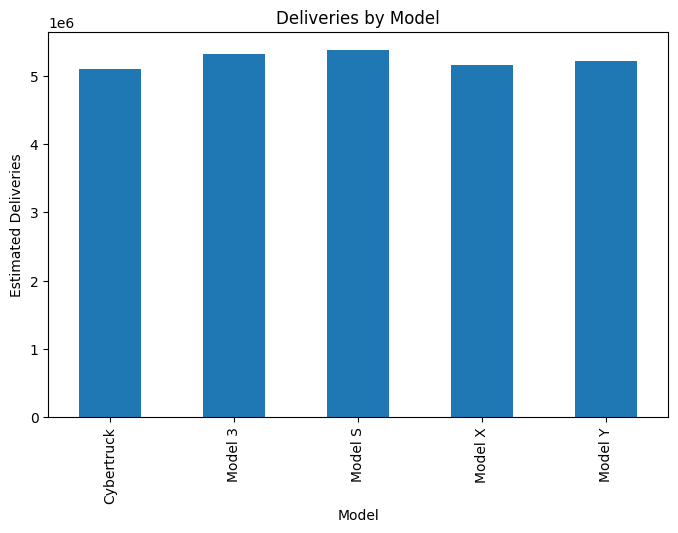

In [ ]:
plt.figure(figsize = (8,5))
df.groupby("Model")["Estimated_Deliveries"].sum().plot(kind="bar")
plt.title("Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.show()

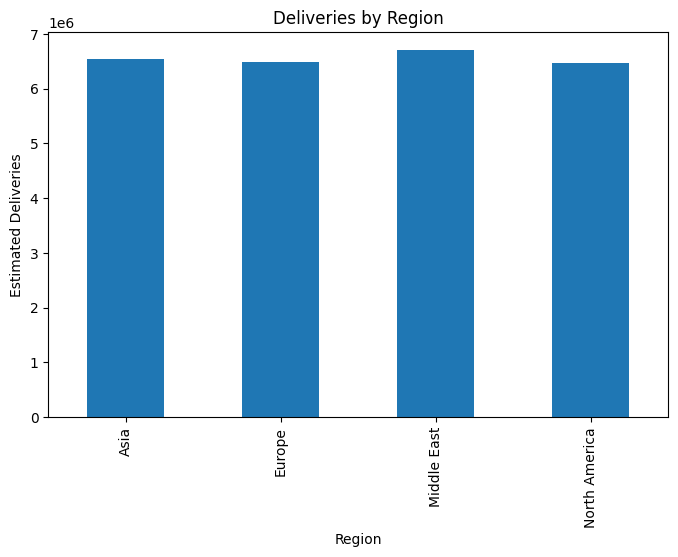

In [ ]:
plt.figure(figsize=(8,5))
df.groupby("Region")["Estimated_Deliveries"].sum().plot(kind="bar")
plt.title("Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.show()

##Correlation Analysis

>A correlation heatmap was used to measure the strength of relationships between numerical features. Highly correlated variables provide useful information for prediction, while weakly correlated variables contribute less to the model. Understanding these relationships helps in selecting relevant features.

In [ ]:
import seaborn as sns

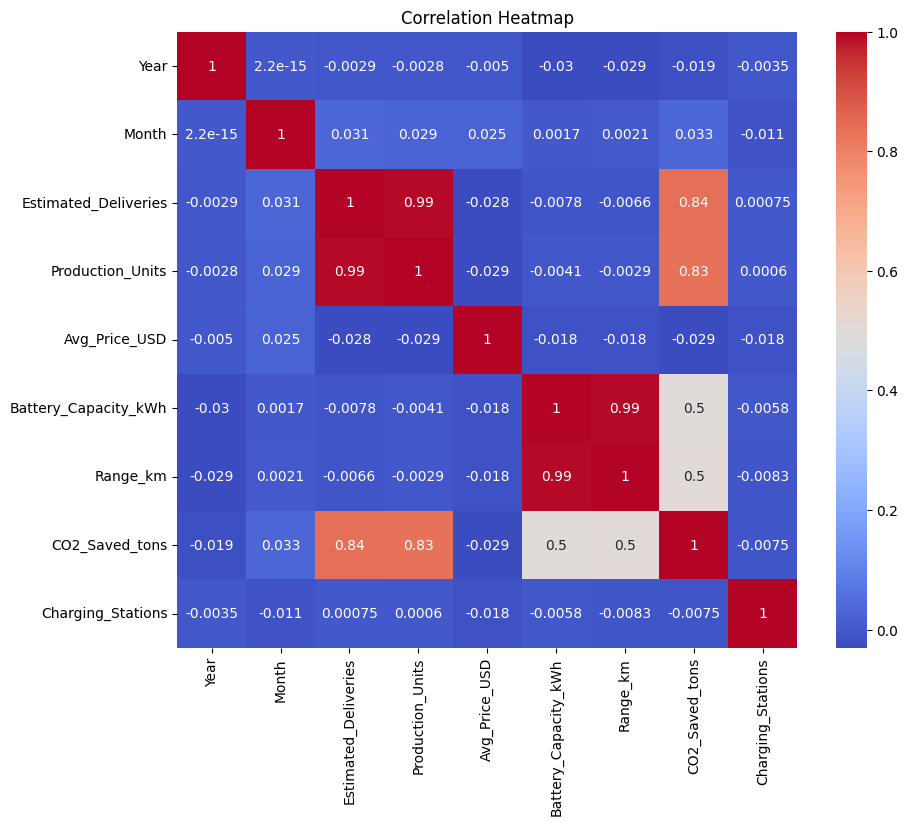

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include = np.number).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

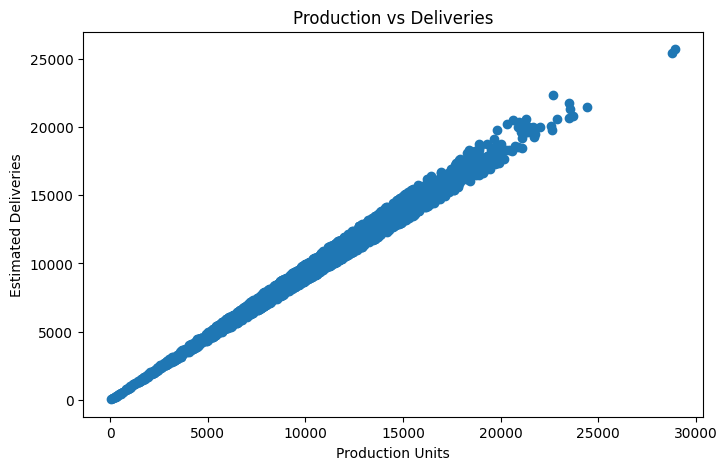

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Production_Units"],df["Estimated_Deliveries"])
plt.title("Production vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.show()

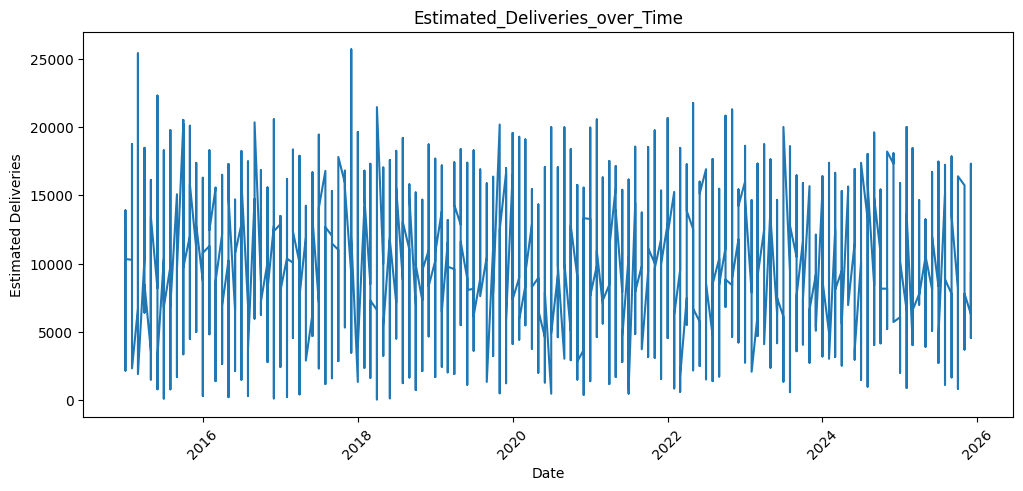

In [ ]:
df["Date"] = pd.to_datetime(df["Year"].astype(str)+"-"+df["Month"].astype(str))
df = df.sort_values("Date")

plt.figure(figsize=(12,5))
plt.plot(df["Date"],df["Estimated_Deliveries"])

plt.title("Estimated_Deliveries_over_Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=45)
plt.show()

## Feature Engineering


>Several new features were created to improve prediction performance.

* Region, Model, and Source Type were converted into numerical values using Label Encoding.
* A one-period lag feature (Deliveries_Lag1) was created to capture previous delivery information.

* A three-period rolling mean feature (Rolling_Mean_3) was generated to smooth short-term fluctuations and capture delivery trends.



In [ ]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"]= le_model.fit_transform(df["Source_Type"])

In [ ]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)
df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean(),inplace=True)

/tmp/ipykernel_4105/3818728488.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean(),inplace=True)


In [ ]:
df["Rolling_Mean_3"] = df["Estimated_Deliveries"].rolling(3).mean()
df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean() , inplace=True)

/tmp/ipykernel_4105/799686189.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean() , inplace=True)


##Train-Test Split

>The dataset was divided chronologically into training and testing sets using an 80:20 ratio.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
target = "Estimated_Deliveries"

x = df.drop(columns=["Estimated_Deliveries","Date"])
y = df[target]

In [ ]:
split = int(len(df)*0.8)

In [ ]:
x_train = x.iloc[:split]
x_test = x.iloc[split:]

In [ ]:
y_train = y.iloc[:split]
y_test = y.iloc[split:]

## Linear Regression Model

>A Linear Regression model was trained to predict Tesla's estimated deliveries. Model performance was evaluated using:

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* R² Score

>An Actual vs Predicted plot was also generated to visually compare the model's predictions with the actual delivery values.

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
pred = model.predict(x_test)

In [ ]:
print("MAE :",mean_absolute_error(y_test,pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))
print("R2 :", r2_score(y_test,pred))

MAE : 323.1618494305049
RMSE : 392.2207507853485
R2 : 0.988429413421087


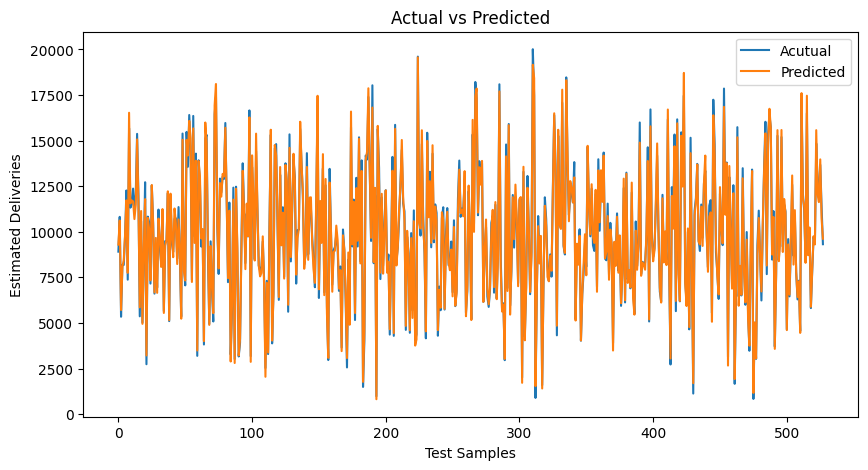

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values,label="Acutual")
plt.plot(pred,label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Estimated Deliveries")
plt.show()

## Cross Validation

>Five-fold Cross Validation was performed on the Linear Regression model to evaluate its stability and generalization ability. The R² score from each fold was calculated, and the average R² score provides an estimate of the model's overall performance on unseen data.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

cv = KFold(n_splits=5,shuffle=True,random_state=42)

scores = cross_val_score(model, x,y,cv=cv,scoring="r2")

print("R2 Scores:")
print(scores)

print("\nMean R2:",scores.mean())

R2 Scores:
[0.99035621 0.98966915 0.99060219 0.99085371 0.98979346]

Mean R2: 0.9902549458758904


## Random Forest + GridSearchRegressor

>A Random Forest Regressor was optimized using GridSearchCV. Different combinations of the following hyperparameters were tested:

* Number of Trees (50 and 100)
* Maximum Depth (5, 10, None)

>The best-performing model was selected automatically, and the top ten most important features were visualized using a feature importance plot.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state = 42)

param_grid = {"n_estimators":[50,100],"max_depth":[5,10,None]}

grid = GridSearchCV(rf,param_grid,cv=5,scoring = "r2")

grid.fit(x_train,y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

rf_pred = best_model.predict(x_test)

print("MAE:",mean_absolute_error(y_test,rf_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,rf_pred)))
print("R2:",r2_score(y_test,rf_pred))

Best Parameters:
{'max_depth': None, 'n_estimators': 100}
MAE: 329.8014962121212
RMSE: 411.46793956511624
R2: 0.9872659589152247


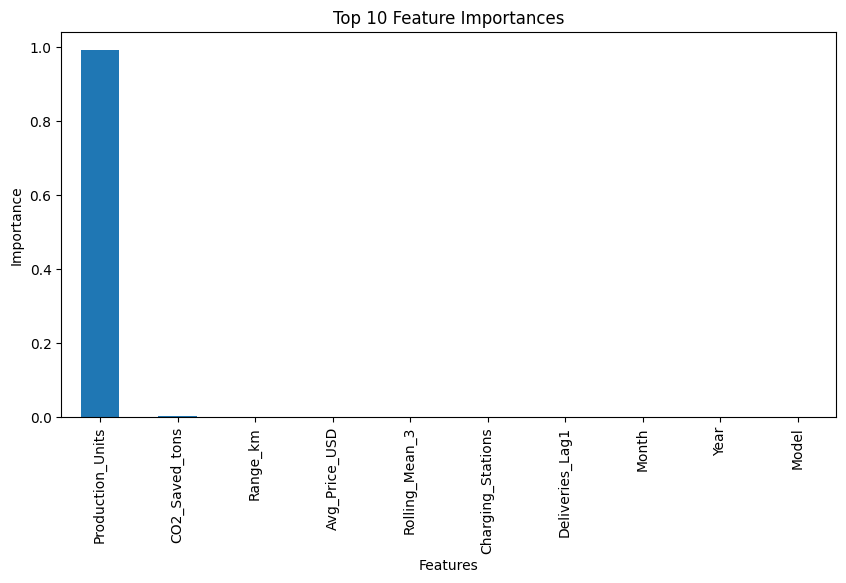

In [ ]:
importance = pd.Series(best_model.feature_importances_,index=x.columns)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

##Augmented Dickey-Fuller (ADF) Test

>The Augmented Dickey-Fuller (ADF) test was applied to the Estimated Deliveries column to determine whether the time series is stationary.

* If the p-value is less than 0.05, the series is considered stationary.
* If the p-value is greater than 0.05, the series is considered non-stationary.

>This test helps determine whether the data is suitable for time series forecasting techniques.

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistics:",result[0])
print("p-value:",result[1])

if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

ADF Statistics: -28.17620446835788
p-value: 0.0
The series is stationary.


In [ ]:
forecast = pd.DataFrame({"Actual":y_test.values,"Predicted":pred})

forecast["Error %"] = (abs(forecast["Actual"]-forecast["Predicted"]/forecast["Actual"]))*100

forecast.head(20)

,Actual,Predicted,Error %
0,8910,9296.809191,8.908957e+05
1,10819,10618.949257,1.081802e+06
2,5341,5709.187855,5.339931e+05
3,8195,8080.715519,8.194014e+05
4,8179,8420.410776,8.177970e+05
5,9742,9827.648802,9.740991e+05
6,12266,11721.844408,1.226504e+06
7,7375,7749.003550,7.373949e+05
8,15680,16528.038659,1.567895e+06
9,11323,11554.405029,1.132198e+06


In [ ]:
forecast.to_csv("forecast_results.csv",index=False)
print("Forecast table saved successfully.")

Forecast table saved successfully.


## Conclusion

>This project successfully demonstrated a complete machine learning workflow for Tesla delivery forecasting. The data was cleaned, explored, and transformed through feature engineering before training predictive models. Linear Regression and Random Forest Regression were evaluated using standard performance metrics, while Cross Validation assessed model reliability. Finally, the Augmented Dickey-Fuller test was used to analyze the stationarity of the delivery data. Overall, the project provides valuable insights into Tesla's delivery patterns and demonstrates how machine learning can be applied for forecasting business data.